In [ ]:
# 패키지 설치

# !pip install statsmodels

In [3]:
# 패키지 준비

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

(526,)
1958-03-31    316.100000
1958-04-30    317.200000
1958-05-31    317.433333
1958-06-30    317.433333
1958-07-31    315.625000
Freq: ME, Name: co2, dtype: float64


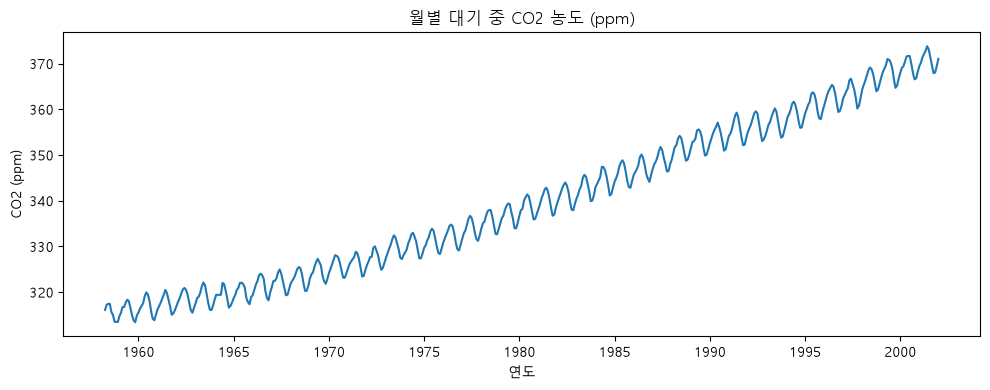

In [7]:
# statsmodels에 내장된 CO2 농도 데이터셋 (1958~2001, 주 단위, 별도 다운로드 불필요)
co2_raw = sm.datasets.co2.load_pandas().data
# co2_raw.shape
co2 = co2_raw['co2'].resample('ME').mean().ffill()  # 월 단위로 리샘플링 + 결측치 보간

print(co2.shape)       # (526,)
print(co2.head())
# # 1958-03-31    316.100
# # 1958-04-30    317.200
# # 1958-05-31    317.433
# # ...


plt.rcParams["font.family"] = "Malgun Gothic"

plt.figure(figsize=(10, 4))
plt.plot(co2.index, co2.values)
plt.title("월별 대기 중 CO2 농도 (ppm)")
plt.xlabel("연도")
plt.ylabel("CO2 (ppm)")
plt.tight_layout()
plt.savefig("co2_raw.png")
# → 뚜렷한 상승 추세(Trend) + 1년 주기의 계절성(Seasonality)이 동시에 보임

In [ ]:
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (N, seq_len, 1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (N, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)
test_dataset = TimeSeriesDataset(X_test, y_test)

# ⚠️ 시계열 DataLoader는 shuffle=False가 원칙
# (배치 "내부" 샘플 순서는 섞여도 되지만, 시간 순서를 벗어난 미래 데이터 누수를 막기 위해
#  전체 분할은 앞서 구현한 시간순 슬라이싱으로 이미 고정했으므로 배치 셔플 자체는 상관없음.
#  다만 관례적으로 시계열 학습에서는 순서를 유지해 디버깅 편의를 높인다.)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [ ]:
def create_sliding_windows(series: np.ndarray, window_size: int):
    """1차원 시계열 배열을 (X, y) 지도학습 쌍으로 변환"""
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i : i + window_size])
        y.append(series[i + window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 12  # 최근 12개월(1년)을 보고 다음 달을 예측

values = co2.values.astype(np.float32)
X, y = create_sliding_windows(values, WINDOW_SIZE)
print(values.shape , X.shape, y.shape)  # (526,) (514, 12) (514,)


(526,) (514, 12) (514,)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# ⚠️ 시계열은 절대 shuffle하면 안 됨 — 시간 순서를 반드시 유지
train_ratio, val_ratio = 0.7, 0.15
n = len(X)
n_train = int(n * train_ratio)
n_val = int(n * (train_ratio + val_ratio))

X_train_raw, y_train_raw = X[:n_train], y[:n_train]
X_val_raw, y_val_raw = X[n_train:n_val], y[n_train:n_val]
X_test_raw, y_test_raw = X[n_val:], y[n_val:]

# 스케일러는 훈련 구간(X_train_raw)만으로 fit
scaler = MinMaxScaler(feature_range=(-1, 1)) # 값을 -1 ~ 1로 조정
scaler.fit(X_train_raw.reshape(-1, 1))

def scale(arr):
    shape = arr.shape
    return scaler.transform(arr.reshape(-1, 1)).reshape(shape)

X_train, y_train = scale(X_train_raw), scale(y_train_raw.reshape(-1, 1)).reshape(-1)
X_val, y_val = scale(X_val_raw), scale(y_val_raw.reshape(-1, 1)).reshape(-1)
X_test, y_test = scale(X_test_raw), scale(y_test_raw.reshape(-1, 1)).reshape(-1)

print(f"train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")
print(f"train={np.min(X_train)}  val={np.min(X_val)}  test={np.min(X_test)}")
print(f"train={np.max(X_train)}  val={np.max(X_val)}  test={np.max(X_test)}")


train=359  val=77  test=78
train=-0.9999990463256836  val=0.7339076995849609  test=1.0858383178710938
train=1.0000019073486328  val=1.4672012329101562  test=1.9626007080078125


In [ ]:
import torch

# unsqueeze가 0이면 (1, N, 12) 가 됨
def to_tensor(X, y):
    X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (N, 12) → (N, 12, 1) # 12개를 한번에 넣기 -> 12개를 1개씩 넣기 ( 1차원 추가 )
    y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (N,)    → (N, 1)
    return X_t, y_t


X_train_t, y_train_t = to_tensor(X_train, y_train)
print(X_train.shape, y_train.shape)  # torch.Size([359, 12, 1]) torch.Size([359, 1])
# print(X_train_t.shape, y_train_t.shape)  # torch.Size([359, 12, 1]) torch.Size([359, 1])


(359, 12) (359,)


In [ ]:
import torch.nn as nn

INPUT_SIZE, HIDDEN_SIZE = 1, 32

rnn_layer = nn.RNN(INPUT_SIZE, HIDDEN_SIZE, batch_first=True)
lstm_layer = nn.LSTM(INPUT_SIZE, HIDDEN_SIZE, batch_first=True)
gru_layer = nn.GRU(INPUT_SIZE, HIDDEN_SIZE, batch_first=True)


for name, layer in [("RNN", rnn_layer), ("LSTM", lstm_layer), ("GRU", gru_layer)]:
    n_params = sum(p.numel() for p in layer.parameters())
    print(f"{name}: {n_params:,} 파라미터")
# RNN:  1,088 파라미터
# LSTM: 4,352 파라미터   (RNN의 정확히 4배 — 게이트 4개 분량: forget/input/candidate/output)
# GRU:  3,264 파라미터   (RNN의 정확히 3배 — 게이트 3개 분량: reset/update/candidate)

# LSTM의 forward는 (output, (h_n, c_n)) 튜플을 반환 — c_n(셀 상태)이 추가로 존재
sample = torch.randn(4, 12, 1)
lstm_out, (h_n, c_n) = lstm_layer(sample)
print(lstm_out.shape, h_n.shape, c_n.shape)
# torch.Size([4, 12, 32]) torch.Size([1, 4, 32]) torch.Size([1, 4, 32])
# 12개 hidden size 결과가 32개가 나와야함 -> (4, 12, 32)

RNN: 1,120 파라미터
LSTM: 4,480 파라미터
GRU: 3,360 파라미터
torch.Size([4, 12, 32]) torch.Size([1, 4, 32]) torch.Size([1, 4, 32])


In [ ]:
# 데이터셋, 데이터로더 구현

from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (N, seq_len, 1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (N, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)
test_dataset = TimeSeriesDataset(X_test, y_test)

# ⚠️ 시계열 DataLoader는 shuffle=False가 원칙
# (배치 "내부" 샘플 순서는 섞여도 되지만, 시간 순서를 벗어난 미래 데이터 누수를 막기 위해
#  전체 분할은 앞서 구현한 시간순 슬라이싱으로 이미 고정했으므로 배치 셔플 자체는 상관없음.
#  다만 관례적으로 시계열 학습에서는 순서를 유지해 디버깅 편의를 높인다.)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [14]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,  # 단일 층이면 dropout 무의미
        )
        self.fc = nn.Linear(hidden_size, 1)  # 마지막 은닉 상태 → 다음 값 1개 예측

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, (h_n, c_n) = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]   # 마지막 시점의 은닉 상태만 사용 (batch, hidden_size) -> (배치, 시퀀스, 출력값)
        return self.fc(last_hidden)         # (batch, 1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMForecaster(input_size=1, hidden_size=64, num_layers=2).to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print(f"총 파라미터 수: {n_params:,}")  # 약 84,000개


LSTMForecaster(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
총 파라미터 수: 50,497


In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        # RNN 계열은 기울기 폭주 방지를 위해 클리핑을 관례적으로 적용
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)

criterion = nn.MSELoss()          # 회귀 문제 — 평균 제곱 오차
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

EPOCHS = 100
best_val_loss = float("inf")
patience, patience_counter = 15, 0
history = {"train_loss": [], "val_loss": []}

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = eval_epoch(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_lstm_co2.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Epoch {epoch}: 조기 종료 (검증 손실 {patience}회 연속 개선 없음)")
            break

    if epoch % 10 == 0 or epoch == 1:
        print(f"[Epoch {epoch:3d}] train_loss={train_loss:.5f}  val_loss={val_loss:.5f}")


[Epoch   1] train_loss=0.01419  val_loss=0.00877
[Epoch  10] train_loss=0.00253  val_loss=0.00447
[Epoch  20] train_loss=0.00379  val_loss=0.01468
[Epoch  30] train_loss=0.00186  val_loss=0.00301
[Epoch  40] train_loss=0.00140  val_loss=0.00260
[Epoch  50] train_loss=0.00135  val_loss=0.00266
[Epoch  60] train_loss=0.00122  val_loss=0.00273
Epoch 66: 조기 종료 (검증 손실 15회 연속 개선 없음)


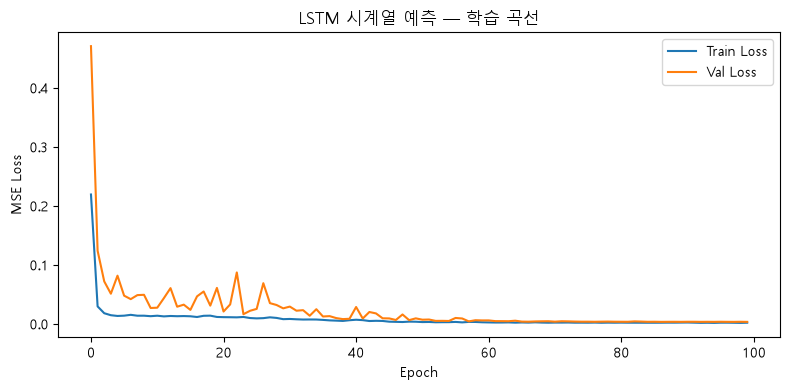

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("LSTM 시계열 예측 — 학습 곡선")
plt.tight_layout()
plt.savefig("lstm_training_curve.png")


RMSE: 3.592 ppm
MAE:  3.123 ppm


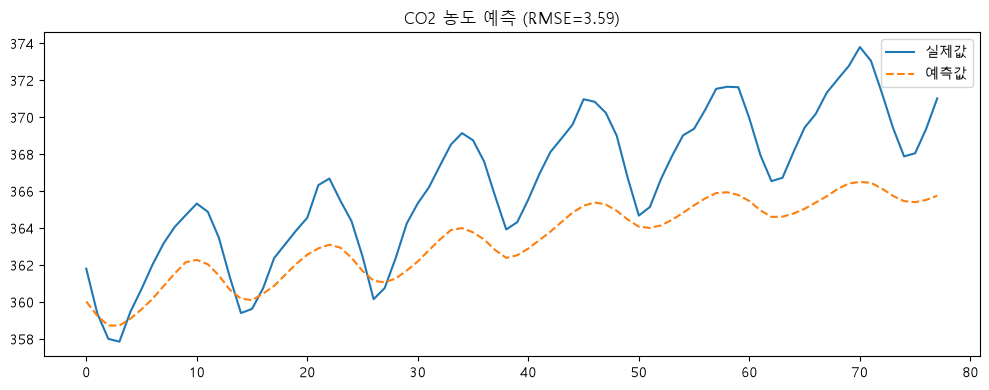

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

model.load_state_dict(torch.load("best_lstm_co2.pt"))
model.eval()

with torch.no_grad():
    X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1).to(device)
    pred_scaled = model(X_test_t).cpu().numpy().reshape(-1, 1)

# 정규화를 되돌려 실제 ppm 단위로 비교
pred_ppm = scaler.inverse_transform(pred_scaled).reshape(-1)
true_ppm = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

rmse = np.sqrt(mean_squared_error(true_ppm, pred_ppm))
mae = mean_absolute_error(true_ppm, pred_ppm)
print(f"RMSE: {rmse:.3f} ppm")
print(f"MAE:  {mae:.3f} ppm")

plt.figure(figsize=(10, 4))
plt.plot(true_ppm, label="실제값")
plt.plot(pred_ppm, label="예측값", linestyle="--")
plt.legend()
plt.title(f"CO2 농도 예측 (RMSE={rmse:.2f})")
plt.tight_layout()
plt.savefig("lstm_prediction_vs_actual.png")
